In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dados = pd.read_csv('../tabelas/analise_dados.csv')


# 6.1 O que é aprendizado de máquina?

- uma subárea da inteligência artificial que capacita os computadores a aprenderem padrões a partir de dados, sem serem explicitamente programados.

Tipos de aprendizados:

- **Supervisionado**: Um exemplo cotidiano é um algoritmo de recomendação de filmes, que aprende com dados de usuários (classificados como "gostei" ou "não gostei") para sugerir filmes similares.
- **Não supervisionado**: Um exemplo seria a segmentação de clientes em grupos com base em seus padrões de compra, sem rótulos prévios.
- **Semi-supervisionado**: Uma aplicação é a classificação de e-mails como spam ou não spam, onde apenas alguns e-mails são rotulados inicialmente, mas o algoritmo pode aprender com os padrões presentes nos dados.
- **Por reforço**: Pode ser exemplificado por um algoritmo que aprende a jogar xadrez, recebendo feedback positivo ou negativo com base nas jogadas.

Além disso, destacamos a diferença entre regressão e classificação:

- **Regressão**: Prevê valores contínuos. Por exemplo, prever o preço de uma casa com base em suas características, como tamanho, localização, número de quartos, etc.
- **Classificação**: Prevê classes ou categorias discretas. Um exemplo seria classificar e-mails como spam ou não spam, com base em seus atributos.

Propusemos um modelo de regressão simples neste módulo, e aprendemos que a regressão é um método estatístico usado para modelar a relação entre uma ou mais variáveis independentes e uma variável dependente. Um exemplo cotidiano disso seria prever a quantidade de vendas de um produto com base no seu preço e nas despesas com publicidade.

- Numa receita de bolo temos esses ingredientes, a nota final é o quão bom o bolo após de acordo com a quantidade de cada ingrediente.

![../img/bolo_mod6.png](../img/bolo_mod6.png)


# 6.2 Preparação de dados (parte 1) - Pré-processamento dos dados

In [4]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,False,True
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,False,True
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True


In [5]:
# filtra apenas os dados das pessoas que estão empregadas como CLT
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [6]:
print(dados["QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?"].value_counts())

QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)                                                    2762
Empreendedor ou Empregado (CNPJ)                                    410
Desempregado, buscando recolocação                                  350
Estagiário                                                          188
Servidor Público                                                    156
Trabalho na área Acadêmica/Pesquisador                               86
Somente Estudante (graduação)                                        82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil      69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil        46
Somente Estudante (pós-graduação)                                    44
Freelancer                                                           39
Prefiro não informar                                                 24
Desempregado e não estou buscando recolocação                        15
Name: count, dtype: int64


In [7]:
dados = dados[dados["QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?"] == "Empregado (CLT)"]
print(dados["QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?"].value_counts())


QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)    2762
Name: count, dtype: int64


In [8]:
# vamos retirar os dadosque são amostras muito pequenas que podem acabar interferindo no nosso modelo
print(dados['COR/RACA/ETNIA'].value_counts())

COR/RACA/ETNIA
Branca                  1805
Parda                    661
Preta                    181
Amarela                   85
Prefiro não informar      16
Outra                     10
Indígena                   4
Name: count, dtype: int64


In [9]:
lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']
dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,False,True
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,False,True
6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,São Paulo (SP),...,Não estou buscando e não pretendo mudar de emp...,Oportunidade de aprendizado e trabalhar com re...,Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Análise de Dados,"SQL, Python, SAS/Stata",False,False
7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Rio Grande do Sul (RS),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Propósito do trabalho e d...",Modelo 100% presencial,Modelo 100% remoto,Vou procurar outra oportunidade no modelo 100%...,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,"SQL, JavaScript",True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,São Paulo (SP),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,False,True
4263,02ido3x5siue5if02iz2taqjmcnh58xh,26.0,25-29,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,Rio de Janeiro (RJ),...,Não estou buscando e não pretendo mudar de emp...,"Remuneração/Salário, Benefícios, Plano de carr...",Modelo 100% remoto,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,

In [10]:
# Depois disso criamos uma coluna chamada “NÃO_BRANCA”, aonde, se na coluna de “COR/RACA/ETNIA” for “branca” essa coluna recebe 0, e caso contrário recebe 1.
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x != 'Branca' else 0)

In [11]:
# Vamos para a coluna de “QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?” e usamos a função extract para pegar o primeiro dígito que aparece em cada opção dessa coluna. Aplicamos o mesmo para a coluna de “NÚMERO DE FUNCIONÁRIOS”. 
print(dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts())

QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?
de 1 a 2 anos                             752
de 3 a 4 anos                             586
de 4 a 6 anos                             423
Menos de 1 ano                            358
Mais de 10 anos                           281
de 7 a 10 anos                            235
Não tenho experiência na área de dados    127
Name: count, dtype: int64


In [12]:
dados['TEMPO DE EXPERIÊNCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [13]:
dados['TEMPO DE EXPERIÊNCIA'].value_counts()

TEMPO DE EXPERIÊNCIA
1     1110
3      586
4      423
10     281
7      235
Name: count, dtype: int64

In [14]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

NUMERO DE FUNCIONARIOS
Acima de 3.000      1325
de 101 a 500         508
de 1.001 a 3.000     371
de 501 a 1.000       251
de 51 a 100          151
de 11 a 50           114
de 6 a 10             24
de 1 a 5              18
Name: count, dtype: int64

In [15]:
dados['NUMERO DE FUNCIONARIOS'].str.replace('.','')

1       Acima de 3000
2       Acima de 3000
3       Acima de 3000
6       Acima de 3000
7           de 6 a 10
            ...      
4262    de 501 a 1000
4263    de 501 a 1000
4266    Acima de 3000
4267      de 51 a 100
4270    de 501 a 1000
Name: NUMERO DE FUNCIONARIOS, Length: 2762, dtype: str

In [16]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '')

In [17]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

NUMERO DE FUNCIONARIOS
Acima de 3000     1325
de 101 a 500       508
de 1001 a 3000     371
de 501 a 1000      251
de 51 a 100        151
de 11 a 50         114
de 6 a 10           24
de 1 a 5            18
Name: count, dtype: int64

In [18]:
dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

,0
1,3000
2,3000
3,3000
6,3000
7,6
...,...
4262,501
4263,501
4266,3000
4267,51


In [19]:

dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [20]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

NUMERO DE FUNCIONARIOS
3000    1325
101      508
1001     371
501      251
51       151
11       114
6         24
1         18
Name: count, dtype: int64

In [21]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

NUMERO DE FUNCIONARIOS
3000    1325
101      508
1001     371
501      251
51       151
11       114
6         24
1         18
Name: count, dtype: int64

# 6.2 Preparação dos dados (parte 2)

Desta vez nós criamos uma coluna chamada “INSATISFACAO”, que a partir da coluna existente 'Qual o principal motivo da sua insatisfação com a empresa atual?' colocava o valor igual a 1 para toda frase que continha a palavra “Salário”.

In [22]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

Qual o principal motivo da sua insatisfação com a empresa atual?
Gostaria de trabalhar em em outra área de atuação                                                                                                           71
Salário atual não corresponde ao mercado                                                                                                                    53
Falta de oportunidade de crescimento no emprego atual                                                                                                       46
Falta de maturidade analítica na empresa                                                                                                                    46
Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa                   28
                                                                                                                                            

In [23]:
dados['INSATISFAÇÃO'] = 0

In [24]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if ' Salário' in x else 0)

1       0
2       0
7       1
10      0
26      1
       ..
4227    0
4234    0
4238    0
4240    0
4270    0
Name: Qual o principal motivo da sua insatisfação com a empresa atual?, Length: 672, dtype: int64

In [25]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFAÇÃO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if ' Salário' in x else 0)

In [26]:
dados['INSATISFAÇÃO'].value_counts()

INSATISFAÇÃO
0    2620
1     142
Name: count, dtype: int64

Nós substituímos cada categoria da coluna de ‘NIVEL DE ENSINO’ por um valor. Na ordem crescente de escolaridade, por exemplo: 0 para “Não tenho graduação formal”, 1 para “Estudante de Graduação”, 2 para “Graduação-Bacharelado”, e assim por diante. 

In [27]:
dados['NIVEL DE ENSINO'].value_counts()

NIVEL DE ENSINO
Graduação/Bacharelado         1038
Pós-graduação                  987
Mestrado                       309
Estudante de Graduação         272
Doutorado ou Phd               100
Não tenho graduação formal      52
Prefiro não informar             4
Name: count, dtype: int64

In [28]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x == 'Não tenho graduação formal' else 
                                                                    1 if x == 'Estudante de Graduação' else 
                                                                    2 if x == 'Graduação/Bacharelado' else 
                                                                    3 if x == 'Pós-graduação' else 
                                                                    4 if x == 'Mestrado' else 
                                                                    5 if x == 'Doutorado ou Phd' else -1)

In [29]:
dados['NIVEL DE ENSINO'].value_counts()

NIVEL DE ENSINO
 2    1038
 3     987
 4     309
 1     272
 5     100
 0      52
-1       4
Name: count, dtype: int64

# 6.3 Preparação dos dados (parte 3)

selecionamos as colunas que serão os argumentos do nosso modelo de regressão: 'IDADE', 'GENERO', 'NAO_BRANCA','TEMPO_EXPERIENCIA', 'SETOR',  'REGIAO ONDE MORA','NIVEL DE ENSINO',  'NUMERO DE FUNCIONARIOS', 'NOVO_NIVEL','SALARIO' e 'INSATISFACAO'.

In [30]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [31]:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO DE EXPERIÊNCIA', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'NOVO_NIVEL', 'SALARIO', 'INSATISFAÇÃO']]

Aplicamos o get_dummies para as colunas de 'GENERO', 'REGIAO ONDE MORA' e 'NOVO_NIVEL'. Lembrando que usamos o get_dummies aqui pois as categorias não têm uma ordem crescente como em nivel de ensino. 

In [32]:
dados = pd.get_dummies(dados, columns = ['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

Antes de treinar o modelo em si, nós dividimos os dados em dois conjuntos, um de teste (para avaliação do modelo) e um de treinamento (para o treinamento do modelo).

- Separamos os atributos do nosso objetivo (target = salário), e utilizamos uma função chamada train_test_split para fazer a divisão dos dados.

In [38]:
x = dados.drop('SALARIO', axis = 1)
y = dados['SALARIO']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

Depois que a divisão foi realizada, nós usamos a função StandardScaler para padronizar as características, ou seja, normalizar os nossos dados. 

In [39]:
print(x_train.dtypes)

IDADE                                        float64
NAO_BRANCA                                     int64
TEMPO DE EXPERIÊNCIA                         float64
NIVEL DE ENSINO                                int64
NUMERO DE FUNCIONARIOS                         int64
INSATISFAÇÃO                                   int64
GENERO_Masculino                                bool
GENERO_Prefiro não informar                     bool
SETOR_Educação                                  bool
SETOR_Entretenimento ou Esportes                bool
SETOR_Filantropia/ONG's                         bool
SETOR_Finanças ou Bancos                        bool
SETOR_Indústria                                 bool
SETOR_Internet/Ecommerce                        bool
SETOR_Marketing                                 bool
SETOR_Outra Opção                               bool
SETOR_Seguros ou Previdência                    bool
SETOR_Setor Alimentício                         bool
SETOR_Setor Automotivo                        

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.fit_transform(x_test)

# 6.4 Introdução a regressão linear (parte 1)

Nós importamos a função LinearRegression da biblioteca sklearn, criamos um objeto chamado model apartir dessa função. E então enviando os parâmetros de treino na função fit (assim: model.fit(X_train_scaled, y_train)) nós conseguimos treinar o modelo.

In [41]:
model = LinearRegression()
model.fit(X_train_scaled, y_train) # modelo treinado

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Usando a função predict e enviando como parâmetro o conjunto de teste (X_test_scaled) a gente conseguiu fazer as predições desse conjunto. 

In [43]:
y_pred = model.predict(X_test_scaled) # vai exibir os salarios que ele previu

Avaliação do modelo, focamos em três métricas principais para avaliação de modelos de regressão:

- MSE (Mean Squared Error), MAE (Mean Absolute Error) e R² (R-squared). Com os resultados nós concluímos que para um modelo real de produção nosso modelo não seria aceitável.

In [45]:
mse = mean_squared_error(y_test, y_pred)
mse # ficou muito alto, indicando que o modelo náo está com predições precisas

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 6.4 Introdução a regressão linear (parte 2)

Plotamos um gráfico dos valores reais versus os valores preditos pelo modelo e conseguimos perceber que até certo valor de salário, os valores preditos e os reais tem uma certa sintonia. Porém para valores muito altos de salários, as predições são muito distantes.

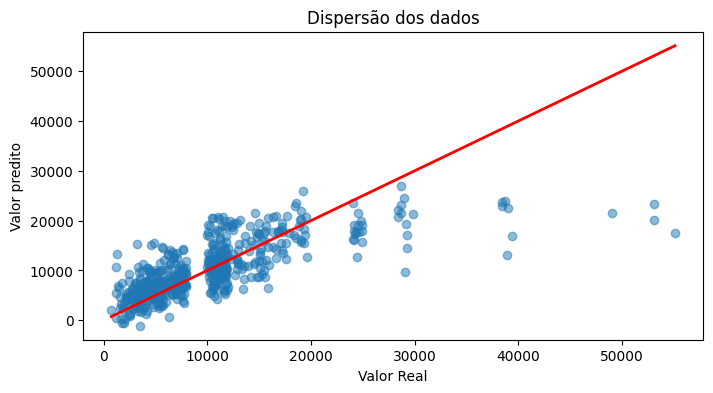

In [50]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha= 0.5)
plt.xlabel("Valor Real")
plt.ylabel("Valor predito")
plt.title('Dispersão dos dados')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.show()

Para conseguir analisar melhor o modelo, nós pegamos os coeficientes (pesos) de cada atributo, assim a gente conseguiu avaliar quais atributos tiveram mais peso positivo ou negativo para o resultado do modelo. Fizemos um gráfico bem bonito pra deixar mais visual essa questão dos coeficientes e conseguimos observar quais atributos pesaram mais para o negativo e quais pesaram mais para o positivo. 

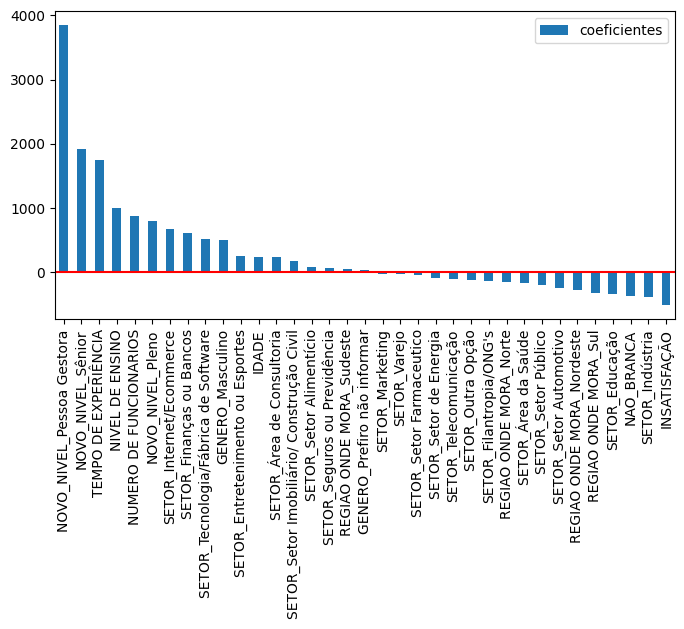

In [66]:
nomes_atributos = x_train.columns
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index=nomes_atributos)
coefs = coefs.sort_values(by='coeficientes', ascending=False)  

coefs.plot.bar(figsize=(8, 4))  
plt.axhline(y=0, color='red') 